In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
# from sdv.metadata import SingleTableMetadata
from numpy.core import multiarray
from sklearn.metrics import r2_score, f1_score, roc_auc_score, roc_curve, auc
from scipy.stats import wasserstein_distance
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('diabetes_dataset.csv')

In [3]:
data

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


In [4]:
data = data[['gender', 'ethnicity', 'income_level', 'smoking_status', 'age', 'physical_activity_minutes_per_week',
 'bmi', 'cholesterol_total', 'insulin_level', 'glucose_fasting', 'diabetes_risk_score', 'heart_rate', 'diagnosed_diabetes']]

In [5]:
data.head()

,gender,ethnicity,income_level,smoking_status,age,physical_activity_minutes_per_week,bmi,cholesterol_total,insulin_level,glucose_fasting,diabetes_risk_score,heart_rate,diagnosed_diabetes
0,Male,Asian,Lower-Middle,Never,58,215,30.5,239,6.36,136,29.6,68,1
1,Female,White,Middle,Former,48,143,23.1,116,2.00,93,23.0,67,0
2,Male,Hispanic,Middle,Never,60,57,22.2,213,5.07,118,44.7,74,1
3,Female,Black,Low,Never,74,49,26.8,171,5.28,139,38.2,68,1
4,Male,White,Middle,Never,46,109,21.2,210,12.74,137,23.5,67,1


In [6]:
data = data.dropna()

In [7]:
data.shape

(100000, 13)

In [8]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from deap import base, creator, tools, algorithms
import random

In [9]:
# def train(X: pd.DataFrame, y: pd.Series, model):
#     mape_arr = []
#     r2_arr = []
    
#     for _ in range(5):
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
#         model.fit(X_train, y_train)
#         prediction = model.predict(X_test)
        
#         mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
#         r2_arr.append(r2_score(y_test.values, prediction))
        
    
#     return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
#             'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [63]:
X_ex, y_ex = data.drop('diagnosed_diabetes', axis=1), data['diagnosed_diabetes']

# xgb = XGBRegressor()

# train(X, y, xgb)

In [64]:
# num_columns = X_ex.select_dtypes(include=[np.number]).columns.tolist()
# cat_columns = np.setdiff1d(X_ex.columns, num_columns)
num_columns = ['age', 'physical_activity_minutes_per_week',
 'bmi', 'cholesterol_total', 'insulin_level', 'heart_rate', 'diabetes_risk_score', 'glucose_fasting']
cat_columns = ['gender', 'ethnicity', 'income_level', 'smoking_status']

length_cat_ordinal = len(cat_columns)
# length_cat_onehot = []
# # length_num = len(X.iloc[0])
length_num = len(num_columns)

length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}

In [65]:
CAT_CARD = list(data[cat_columns].apply(lambda x: len(x.unique()), axis=0).values.flatten())

## Baseline

In [66]:
def split_and_transform(X: pd.DataFrame, y: pd.DataFrame):
    scalers = {'scaler_X': MinMaxScaler(), 'scaler_y': MinMaxScaler(), 'ord_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}
    
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
    
    if length_dict['length_cat_ordinal'] == 0:
        X_train = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train))
        X_test = pd.DataFrame(scalers['scaler_X'].transform(X_test))
        y_train = pd.DataFrame(scalers['scaler_y'].fit_transform(y_train.values.reshape(-1, 1)))
        y_test = pd.DataFrame(scalers['scaler_y'].transform(y_test.values.reshape(-1, 1)))
        
        
    elif length_dict['length_cat_ordinal'] != 0:
        X_train[cat_columns] = pd.DataFrame(scalers['ord_encoder'].fit_transform(X_train[cat_columns]))
        X_test[cat_columns] = pd.DataFrame(scalers['ord_encoder'].transform(X_test[cat_columns]))
        
        X_train[num_columns] = pd.DataFrame(scalers['scaler_X'].fit_transform(X_train[num_columns]))
        X_test[num_columns] = pd.DataFrame(scalers['scaler_X'].transform(X_test[num_columns]))
        
        y_train = pd.DataFrame(y_train.values.reshape(-1, 1).astype(float))
        y_test = pd.DataFrame(y_test.values.reshape(-1, 1).astype(float))
        
    return X_train, X_test, y_train, y_test, scalers


def train_model(model_type, X_train, y_train):
    model = model_type
    model.fit(X_train, y_train)
    
    return model


def evaluate_model(model_type, X, y):
    metrics = {'mse': [], 'r2': [], 'mape': []}
    
    for _ in range(31):
        X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        model = train_model(model_type, X_train, y_train)
        
        prediction = model.predict(X_test)
    
        metrics['F1'].append(f1_score(y_test.values, prediction))
        metrics['ROCAUC'].append(roc_auc_score(y_test.values, prediction))
        metrics['mape'].append(mean_absolute_percentage_error(y_test.values, prediction))
    
    metrics_df = pd.DataFrame([[np.mean(metrics['F1']), np.std(metrics['F1'])],
                               [np.mean(metrics['ROCAUC']), np.std(metrics['ROCAUC'])],
                               [np.mean(metrics['mape']), np.std(metrics['mape'])]], columns=['MEAN', 'STD'], index=['mse', 'r2', 'mape'])
        
    return metrics_df.round(3)

In [67]:
X_train, X_test, y_train, y_test, scalers = split_and_transform(X_ex, y_ex)

In [68]:
baseline_model = train_model(RandomForestClassifier(n_estimators=200, max_depth=3), X_train, y_train)
new_model = train_model(XGBClassifier(n_estimators=200, max_depth=3), X_train, y_train)

In [69]:
baseline_prediction = baseline_model.predict(X_test).flatten()
baseline_prediction_proba = baseline_model.predict_proba(X_test)[:, 1].flatten()

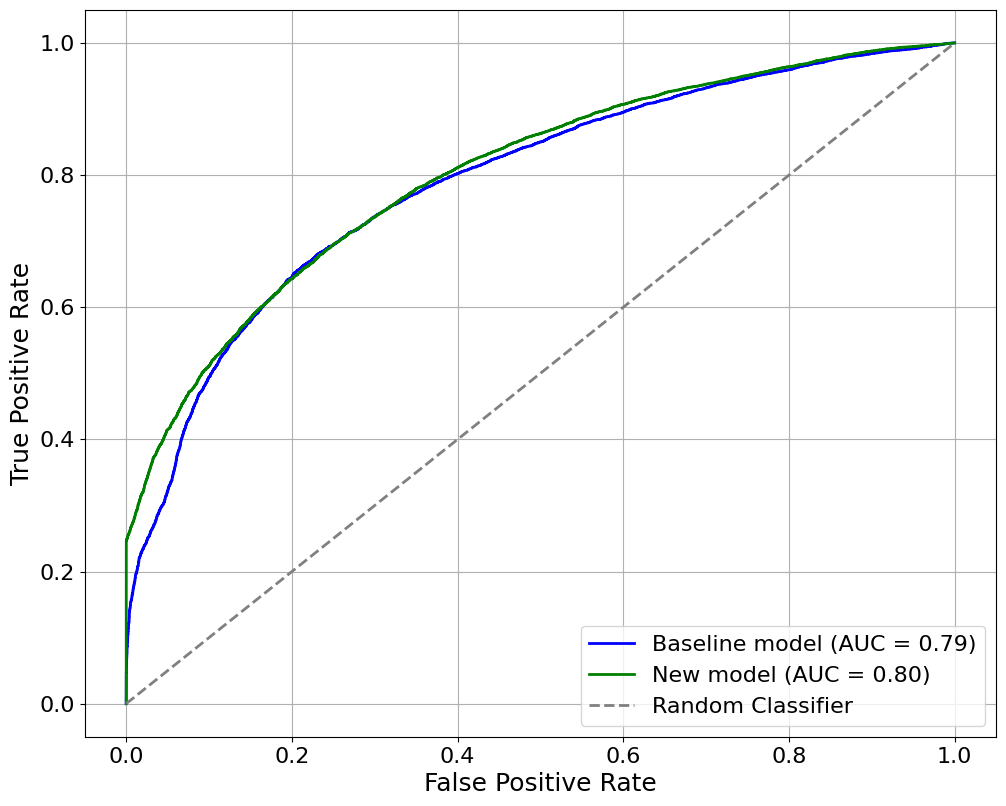

In [70]:
fpr1, tpr1, _ = roc_curve(y_test, baseline_model.predict_proba(X_test)[:, 1])
roc_auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(y_test, new_model.predict_proba(X_test)[:, 1])
roc_auc2 = auc(fpr2, tpr2)

# 7. Plot the ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, color='blue', lw=2, label=f'Baseline model (AUC = {roc_auc1:.2f})')
plt.plot(fpr2, tpr2, color='green', lw=2, label=f'New model (AUC = {roc_auc2:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right', fontsize=16)
plt.grid(True)


plt.tight_layout(pad=0.5)
# plt.savefig('images/roc_test_data.pdf', dpi=300)
plt.show()

In [71]:
# df_proba = pd.DataFrame(baseline_prediction_proba, columns=['proba'])
# df_proba['class'] = baseline_prediction
# df_proba = df_proba[(df_proba['class'] == 1.0) & (df_proba['proba'] < 0.501) | (df_proba['class'] == 0.0) & (1 - df_proba['proba'] < 0.501) ]

## Select bad examples

In [72]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, predictions_proba: np.array, thrs: float = 0.501):
    # idx_bad = np.where(predictions != y.values.flatten())[0]
    # idx_bad = idx_bad[:int(len(idx_bad) * thrs)]
    df_proba = pd.DataFrame(predictions_proba, columns=['proba'])
    df_proba['class'] = predictions
    df_proba = df_proba[(df_proba['class'] == 1.0) & (df_proba['proba'] <= thrs) | (df_proba['class'] == 0.0) & (1 - df_proba['proba'] <= thrs) ]
    idx_bad = df_proba.index.values
    
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [73]:
bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, baseline_prediction_proba, 0.505)

In [74]:
len(bad_X) / len(X_test)

0.0139

In [75]:
# idx_bad = np.where(np.abs(y_test.values - xgb_pred) > 0.05)[0]
# bad_y = y_test.iloc[idx_bad]
# bad_X = X_test.loc[y_test.iloc[idx_bad].index]

In [76]:
bad_X

,gender,ethnicity,income_level,smoking_status,age,physical_activity_minutes_per_week,bmi,cholesterol_total,insulin_level,glucose_fasting,diabetes_risk_score,heart_rate
7,0.0,4.0,2.0,2.0,0.722222,0.066026,0.392562,0.661905,0.116148,0.241071,0.477519,0.400000
52,1.0,3.0,1.0,0.0,0.402778,0.267707,0.264463,0.423810,0.000000,0.392857,0.533333,0.446154
66,0.0,0.0,3.0,0.0,0.402778,0.223289,0.623967,0.452381,0.000000,0.285714,0.606202,0.400000
78,0.0,2.0,2.0,2.0,0.388889,0.182473,0.446281,0.371429,0.222700,0.339286,0.582946,0.538462
137,0.0,4.0,2.0,1.0,0.305556,0.182473,0.438017,0.561905,0.000000,0.437500,0.345736,0.353846
...,...,...,...,...,...,...,...,...,...,...,...,...
19906,1.0,4.0,2.0,1.0,0.111111,0.027611,0.404959,0.290476,0.255129,0.437500,0.336434,0.569231
19911,1.0,4.0,4.0,2.0,0.722222,0.098439,0.458678,0.542857,0.000000,0.419643,0.449612,0.615385
19924,1.0,0.0,2.0,2.0,0.763889,0.192077,0.400826,0.428571,0.160159,0.410714,0.449612,0.384615
19925,2.0,4.0,2.0,2.0,0.416667,0.174070,0.301653,0.309524,0.409662,0.366071,0.527132,0.400000


In [77]:
# plt.figure(figsize=(8, 8))

# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(y_test.values, baseline_prediction, color='tab:blue', alpha=0.7, label='Test prediction', zorder=3, edgecolors='none', s=50)
# plt.scatter(bad_y, baseline_model.predict(bad_X), color='tab:red', alpha=0.7, label='Bad prediction', zorder=3, edgecolors='none', s=50)

# plt.xlabel('True')
# plt.ylabel('Prediction')
# plt.legend()

# plt.tight_layout(pad=0.5)
# # plt.savefig('images/prediction_bad_moscow.pdf', dpi=300)
# plt.show()

In [78]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2


def custom_crossover_num_ord(ind1, ind2, cat_indpb=0.3, num_eta=10):
    cat1 = ind1[:length_cat_ordinal]
    cat2 = ind2[:length_cat_ordinal]
    num1 = ind1[length_cat_ordinal:]
    num2 = ind2[length_cat_ordinal:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2


# def custom_crossover_num_ord_nominal(ind1, ind2, cat_indpb=0.3, num_eta=10):
#     onehot1 = ind1[:sum(length_cat_onehot)]
#     onehot2 = ind2[:sum(length_cat_onehot)]
#     cat1 = ind1[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     cat2 = ind2[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
#     num1 = ind1[-length_num:]
#     num2 = ind2[-length_num:]

#     cat1_copy = copy.deepcopy(list(cat1))
#     cat2_copy = copy.deepcopy(list(cat2))
#     num1_copy = copy.deepcopy(list(num1))
#     num2_copy = copy.deepcopy(list(num2))

#     tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

#     low = [0.0] * len(num1_copy)
#     up = [1.0] * len(num1_copy)
#     tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

#     ind1[:] = cat1_copy + num1_copy
#     ind2[:] = cat2_copy + num2_copy

#     return ind1, ind2

In [79]:
# def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate # * weights[i]
        
#         if random.random() < mutation_prob:
#             coef = linear_coefs[i]
#             direction = 1 if coef * target_direction >= 0 else -1
            
#             # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#             noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
#             individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,


def custom_mutate_num_ord(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate #* weights[i]
        
        if random.random() < mutation_prob:
            if i < length_dict['length_cat_ordinal']: 
                individual[i] = random.sample(list(bad_X.iloc[:, i].unique()), 1)[0]
            else: 
                # idx = i - len(cat_cols_name)
                # coef = linear_coefs[i]
                
                # direction = 1 if coef * target_direction >= 0 else -1
                
                # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
                noise = abs(np.random.normal(0, 0.1 * mutation_strength))
                individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,

In [80]:
lr = LogisticRegression(fit_intercept=False)
lr.fit(X_train, y_train)
linear_coefs = lr.coef_[0]

In [81]:
def augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps: int = 10):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()

    if (length_dict['length_cat_ordinal'] == 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])]))
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num)
            
            
    elif (length_dict['length_cat_ordinal'] != 0) and (length_dict['length_cat_onehot'] == []):
        for i in range(len(cat_columns)):
            toolbox.register(f"cat_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        for i in range(length_dict['length_cat_ordinal'], length_dict['length_cat_ordinal'] + length_dict['length_num']):
            # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
            toolbox.register(f"num_{i - length_dict['length_cat_ordinal']}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        def make_individual():
            return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_dict['length_cat_ordinal'])] + \
                [toolbox.__getattribute__(f"num_{i}")() for i in range(length_dict['length_num'])])
            
        toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        toolbox.register("mate", custom_crossover_num_ord)
        
        
    else:
        return 0
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
        # for i, col in enumerate(cat_cols_name):
        #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
            
        # for i in range(length_num):
        #     # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        #     toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
            
        # def make_individual():
        #     return 0
            
        # toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
        # toolbox.register("population", tools.initRepeat, list, toolbox.individual)
        # toolbox.register("mate", custom_crossover_num_ord_nominal)
        
        


    # def make_individual():
    #     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    #         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
    #             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
            
    #     else:
    #         return 0

    toolbox.register("select", tools.selTournament, tournsize=3)
    
    steps = tqdm(range(len(bad_X)))
    best_individuals = []
    bad_y_sc_arr = []
    prediction_exp = baseline_model.predict(bad_X)
    num_steps = tqdm(range(num_steps))
    

    for _ in num_steps:
        # bad_y_scenario = np.maximum(np.minimum(0.0, y_test.min().values[0]),
                                    # np.minimum(bad_y + np.random.normal(0, 0.1, (len(bad_y), 1)), np.maximum(1.0, y_test.max().values[0])))
        bad_y_scenario = bad_y
    
        
        for i in steps:
            def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
                # prediction = baseline_model.predict([individual])
                # error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
              
                prediction = baseline_model.predict_proba([individual])[0][1]
                y_target_sc = y_target.values[i][0]
               
                if np.random.uniform(0, 1) < 0.3:
                    y_target_sc = 1 - y_target_sc
                
                if y_target_sc == 1.0:
                    error =  - 0.5 * prediction**2 - np.mean( (individual - bad_X.values[i])**2 )
                else:
                    error =  - 0.5 * (1 - prediction)**2 - np.mean( (individual - bad_X.values[i])**2 )
                
                                
                total_fitness = error #+ bonus
                return (total_fitness,)
            
            def main(target_direction, y_target):
                toolbox.register("evaluate", eval_func, y_target=y_target, 
                                linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
                # toolbox.unregister("mutate")
                if length_dict['length_cat_ordinal'] == 0:
                    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)
                else:
                    toolbox.register("mutate", custom_mutate_num_ord, weights=1, linear_coefs=linear_coefs, 
                                target_direction=target_direction)

                pop = toolbox.population(n=30)
                hof = tools.HallOfFame(1, similar=np.array_equal)
                stats = tools.Statistics(lambda ind: ind.fitness.values)
                stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
                stats.register("max", lambda x: max(i[0] for i in x))

                algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
                
                return hof[0]
        
            if bad_y_scenario.values[i] >= prediction_exp[i]:
                target_direction = 1
            else:
                target_direction = -1
            
            
            best_individual = main(target_direction, bad_y_scenario)
            best_individuals.append(best_individual)
            
        bad_y_sc_arr.append(bad_y_scenario.values.flatten())
        
    bad_y_sc_arr = np.hstack(bad_y_sc_arr)
    best_individuals = np.array(best_individuals)
    
    return best_individuals, bad_y_sc_arr

In [82]:
best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, linear_coefs, length_dict, num_steps=5)

100%|██████████| 5/5 [05:58<00:00, 71.78s/it]


In [316]:
# plt.figure(figsize=(8, 8))

# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Identity line')
# plt.scatter(bad_y, baseline_model.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red', zorder=3, edgecolors='none', s=50)
# plt.scatter(bad_y_sc_arr, baseline_model.predict(best_individuals), alpha=0.7, label='GA bad y', color='green', edgecolors='none', s=50)

# plt.xlabel('True')
# plt.ylabel('Prediction')
# plt.legend()

# plt.tight_layout(pad=0.5)
# # plt.savefig('images/prediction_best_ind_moscow.pdf', dpi=300)
# plt.show()

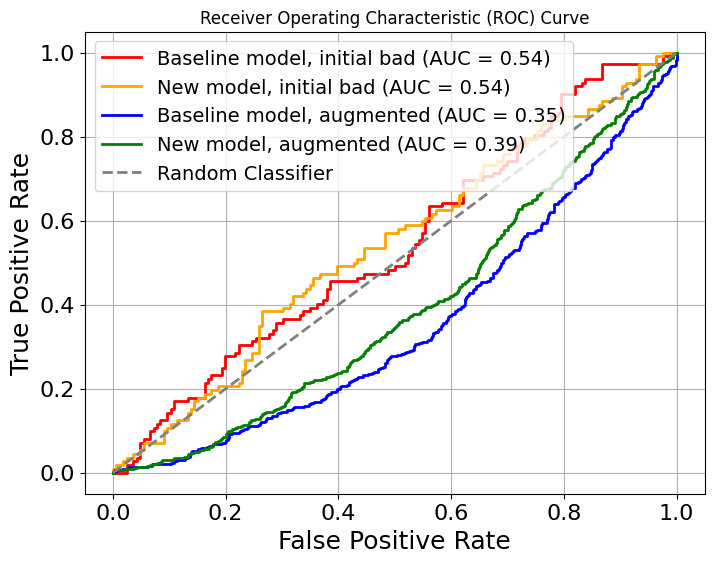

In [83]:
fpr1, tpr1, _ = roc_curve(bad_y, baseline_model.predict_proba(bad_X)[:, 1])
roc_auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(bad_y, new_model.predict_proba(bad_X)[:, 1])
roc_auc2 = auc(fpr2, tpr2)
fpr3, tpr3, _ = roc_curve(bad_y_sc_arr, baseline_model.predict_proba(best_individuals)[:, 1])
roc_auc3 = auc(fpr3, tpr3)
fpr4, tpr4, _ = roc_curve(bad_y_sc_arr, new_model.predict_proba(best_individuals)[:, 1])
roc_auc4 = auc(fpr4, tpr4)

# 7. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, color='red', lw=2, label=f'Baseline model, initial bad (AUC = {roc_auc1:.2f})')
plt.plot(fpr2, tpr2, color='orange', lw=2, label=f'New model, initial bad (AUC = {roc_auc2:.2f})')
plt.plot(fpr3, tpr3, color='blue', lw=2, label=f'Baseline model, augmented (AUC = {roc_auc3:.2f})')
plt.plot(fpr4, tpr4, color='green', lw=2, label=f'New model, augmented (AUC = {roc_auc4:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier') # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='upper left')
plt.grid(True)

plt.show()

In [282]:
# plt.hist(best_individuals[:, 10], bins=40, density=True, alpha=0.6)
# plt.hist(bad_X.iloc[:, 10], bins=40, density=True, alpha=0.6)
# plt.show()

In [65]:
# plt.hist(bad_y, bins=40, density=True, alpha=0.7, label='Initital bad y', color='tab:red')
# plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.7, label='GA bad y', color='green')
# plt.hist(y_test, bins=40, density=True, alpha=0.7, label='y test', color='tab:blue')


# plt.legend()
# plt.xlabel('Target values')
# plt.ylabel('Density')

# plt.tight_layout(pad=0.5)
# # plt.savefig('images/hist_ga_moscow.pdf', dpi=300)
# plt.show()

In [84]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr),
                                         baseline_model.predict(best_individuals),
                                         baseline_model.predict_proba(best_individuals)[:, 1],
                                         thrs=505)

In [85]:
idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
np.random.shuffle(idx_rnd)

augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]

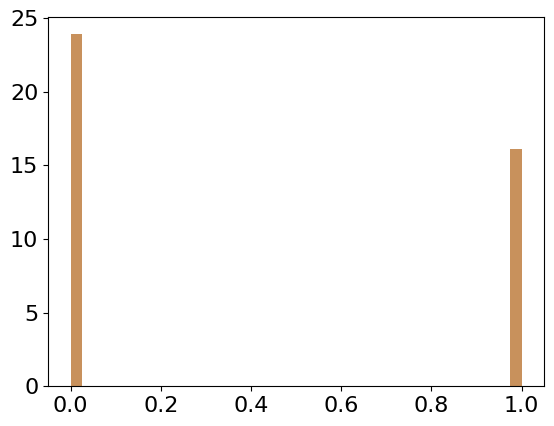

In [86]:
# plt.hist(y_test, density=True, alpha=0.6, bins=40)
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [87]:
augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [88]:
augmented_data.shape

(1668, 13)

## Generator

In [89]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented_data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [90]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.act(out)
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32, cat_cardinalities: list = []):
        super(VAE, self).__init__()
        
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels
        
        
        
        if not cat_cardinalities:
            self.cat_flag = False
            self.h_dim_enc = seq_length * hidden_channels
            self.decoder_reshape_dim = self.seq_length
            self.n_cat = 0
            
        else:
            self.cat_flag = True
            self.emb_dim = 4
            self.n_cat = len(cat_cardinalities)
            self.h_dim_dec = 2**9
            # self.decoder_reshape_dim = (self.h_dim_dec + (self.emb_dim - 1) * self.n_cat)
            self.decoder_reshape_dim = self.h_dim_dec // self.hidden_channels
            self.cat_heads = nn.ModuleList([nn.Linear((self.emb_dim - 1) * self.n_cat, card) for card in cat_cardinalities])

            # self.decoder_with_logit_dim = 
            
            self.embeddings = []
            for card in cat_cardinalities:
                self.embeddings.append(nn.Embedding(card, self.emb_dim))
                
            self.h_dim_enc = (seq_length + (self.emb_dim - 1) * self.n_cat) * hidden_channels 
        

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        # self.fc_mu = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        # self.fc_logvar = nn.Sequential(nn.Linear(latent_dim, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_dec))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        self.condition_encoder_beta = nn.Embedding(2, latent_dim)
        self.condition_encoder_gamma = nn.Embedding(2, latent_dim)
        self.condition_decoder_beta = nn.Embedding(2, self.decoder_reshape_dim)
        self.condition_decoder_gamma = nn.Embedding(2, self.decoder_reshape_dim)
        
        
            
        # if self.cat_flag:
            # self.embedding = nn.Embedding(len(scalers['ord_encoder'].categories_[0]), 2)

        self.proj = nn.Sequential(nn.Linear(self.decoder_reshape_dim - (self.emb_dim - 1) * self.n_cat, 2**6),
                                  self.act,
                                  nn.Linear(2**6, 2**6),
                                  self.act,
                                  nn.Linear(2**6, self.seq_length - self.n_cat))
    
        # self.decoder_proj = nn.Linear(self.decoder_reshape_dim, )
        

    def encode(self, x, y):
        # x: (B, 1, T), y: (B, 1, 1)
        if self.cat_flag:
            emb_list = []
            for i, emb in enumerate(self.embeddings):
                emb_list.append(emb(x[:,:,i].long()))
            emb_list = torch.cat(emb_list, dim=2)
            
            x = torch.cat([x[:,:, self.n_cat:], emb_list], dim=2) #(B, 1, T + (emb_dim - 1) * n_cat)
            
        
        x = self.enc_conv1(x)
        x = self.act(x)
        x = self.enc_res1(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        x = self.enc_res2(x) #(B, hidden_channels, T + (emb_dim - 1) * n_cat)
  
        x = x.view(x.size(0), -1) #(B, hidden_channels * (T + (emb_dim - 1) * n_cat))
 
        mu = self.fc_mu(x) * self.condition_encoder_beta(y.squeeze(1).long()).squeeze(1) + self.condition_encoder_gamma(y.squeeze(1).long()).squeeze(1) #(B, latent_dim)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y.squeeze(1).long()).squeeze(1) + self.condition_encoder_gamma(y.squeeze(1).long()).squeeze(1) #(B, latent_dim)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z, y):
        # z: (B, latent_dim), y: (B, 1, 1)

        x = self.fc_decode(z) #(B, h_dim_dec)
        x = x.view(z.size(0), self.hidden_channels, self.decoder_reshape_dim) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.dec_conv1(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.act(x)
        x = self.dec_res1(x)
        x = self.dec_conv2(x) #(B, hidden_channel, h_dim_dec//hidden_channel)
        
        x = self.dec_res2(x) * self.condition_decoder_beta(y.squeeze(1).long()).repeat(1, self.hidden_channels, 1) +\
            self.condition_decoder_gamma(y.squeeze(1).long()).repeat(1, self.hidden_channels, 1)
        x = self.dec_conv3(x) #(B, 1, h_dim_dec//hidden_channel)
        
        x_cat, x_num = x[:,:, :(self.emb_dim - 1) * self.n_cat], x[:,:, (self.emb_dim - 1) * self.n_cat:] 
        #x_cat: (B, 1, (emb_dim - 1) * n_cat), x_num: (B, 1, T - (emb_dim - 1) * n_cat)
        cat_logits = [head(x_cat) for head in self.cat_heads] if self.n_cat > 0 else []

        x_num = self.proj(x_num) #(B, 1, T - n_cat)
        
        return x_num, cat_logits
    

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z, y)
        
        return recon_x_num, recon_x_logits, mu, logvar
    

def vae_loss(recon_x_num, recon_x_logits, x, mu, logvar, beta, cat_target_flag=False):
    if cat_target_flag:
        recon_num = F.mse_loss(recon_x_num, x[:,:, length_dict['length_cat_ordinal']:-1], reduction='mean')
      
        x_cat = x[:, :, :length_dict['length_cat_ordinal']].squeeze(1).long().transpose(0, 1)

        # Categorical cross-entropy
        recon_cat = torch.tensor(0.0, device=device)
        recon_x_logits = recon_x_logits
     
        cat_losses = []
        for logits, tgt in zip(recon_x_logits, x_cat):
            # logits: [B, card], tgt: [B]
            cat_losses.append(F.cross_entropy(logits.squeeze(1), tgt, reduction='mean'))
        recon_cat = torch.stack(cat_losses).sum()
            
        recon_loss = recon_num + 0.1 * recon_cat
        
    else:
        recon_loss = F.mse_loss(recon_x_num, x[:,:, :-1], reduction='mean')

    
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    return recon_loss + beta * kl_loss

In [91]:
def train_vae(data_tensor, num_epochs = 200, learning_rate = 1e-3, batch_size = 2**6, input_channels = 1, cat_target_flag = True):
    seq_length = data_tensor.size(1) - 1
    train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

    model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16, cat_cardinalities=CAT_CARD)
    model_vae.to(device)
    optimizer = optim.AdamW(model_vae.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.001, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model_vae.train()
    
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_x_num, recon_x_logits, mu, logvar = model_vae(data)
            loss = vae_loss(recon_x_num, recon_x_logits, data, mu, logvar, beta_sch[epoch], cat_target_flag)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model_vae.parameters(), max_norm=3)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
     
        if epoch % 2 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}, LR: {round(optimizer.param_groups[0]["lr"], 4)}')
            
    return model_vae, losses

In [92]:
model_vae, losses = train_vae(data_tensor)

  0%|          | 0/200 [00:00<?, ?it/s]

Average Loss: 0.0007, LR: 0.0001: 100%|██████████| 200/200 [02:05<00:00,  1.59it/s]


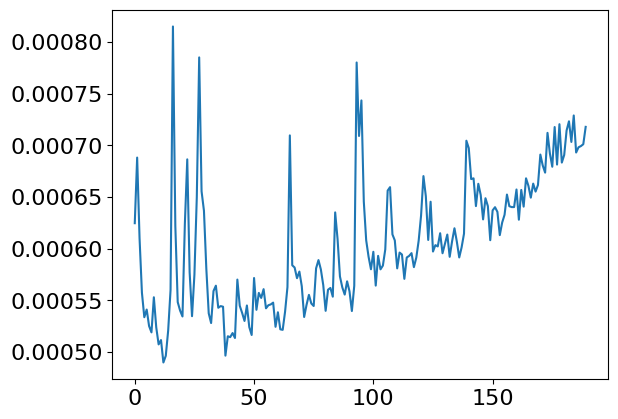

In [93]:
plt.plot(losses[10:])
plt.show()

In [94]:
def generate(model, data_tensor, mult: int = 5) -> np.array:
    synth_vae_arr = []

    for _ in range(mult):
        synth_vae_num, synth_vae_logits, _, _ = model(data_tensor.unsqueeze(1).to(device))
        synth_vae_num = synth_vae_num.squeeze(1).detach().cpu().numpy()
        
        cat_arr = []
        for logits in synth_vae_logits:
            cat_arr.append(logits.squeeze(1).softmax(dim=-1).argmax(dim=-1).long().view(-1, 1).detach().cpu().numpy())
        cat_arr = np.hstack(np.array(cat_arr))
        
        synth_vae = np.concatenate([cat_arr, synth_vae_num], axis=1)
        
        synth_vae_arr.append(synth_vae)
        
    synth_vae = np.vstack(np.array(synth_vae_arr))
    
    return synth_vae #(5*N, T)

In [95]:
model_vae.eval()

VAE(
  (cat_heads): ModuleList(
    (0): Linear(in_features=12, out_features=3, bias=True)
    (1-2): 2 x Linear(in_features=12, out_features=5, bias=True)
    (3): Linear(in_features=12, out_features=3, bias=True)
  )
  (enc_conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_res1): ResidualBlock(
    (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (drop1): Dropout(p=0.1, inplace=False)
    (drop2): Dropout(p=0.1, inplace=False)
  )
  (enc_conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
  (enc_bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_r

In [96]:
synth_vae = generate(model_vae, data_tensor)
synth_vae.shape

(8340, 12)

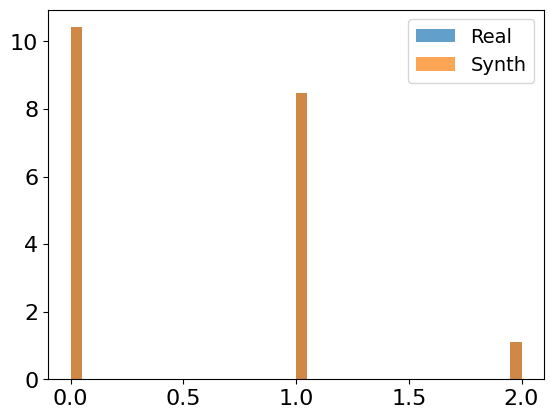

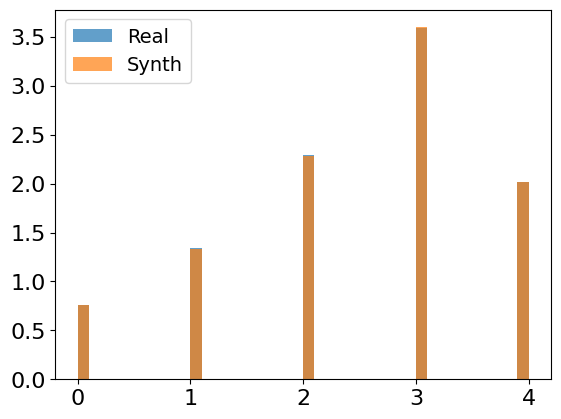

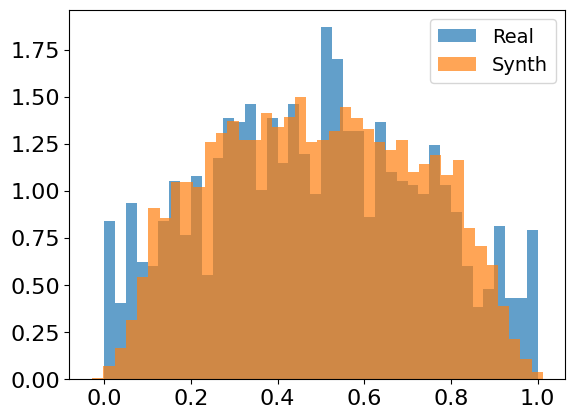

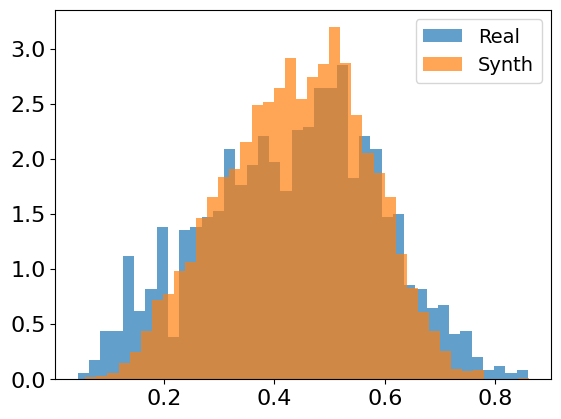

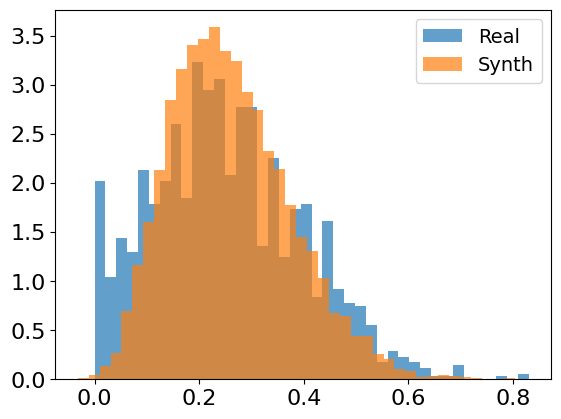

In [97]:
for i in range(0, 10, 2):
    plt.hist(augmented_data[:, i], bins=40, alpha=0.7, density=True, label='Real')
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

    plt.legend()
    plt.show()

In [102]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
# synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae), scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(5).reshape(-1, 1))], axis=1))
synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))

In [ ]:
bad_D = pd.concat([bad_X, bad_y], axis=1)

good_df = pd.concat([X_test.loc[np.setdiff1d(X_test.index.values, bad_X.index.values)],
           pd.DataFrame(y_test.loc[np.setdiff1d(X_test.index.values, bad_X.index.values)].values, columns=['target'])], axis=1).dropna()
good_df[['gender', 'ethnicity', 'income_level', 'smoking_status']] = good_df[['gender', 'ethnicity', 'income_level', 'smoking_status']].astype(int).astype('str')

In [237]:
# !pip install prince

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# pca = PCA(n_components=2)
# pca_components1 = pca.fit_transform(bad_D.values[:, 4:-1])
# pca_components2 = pca.transform(augmented_data[:, 4:-1])
# pca_components3 = pca.transform(synth_df.values[:, 4:-1])

pca = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_combined = np.vstack([bad_D.values[:, :], augmented_data[:, :], synth_df.values[:, :], good_df.values[:, :]])
scaler = StandardScaler()
X_combined = scaler.fit_transform(X_combined)

pca_components = pca.fit_transform(X_combined)
pca_components1 = pca_components[:len(bad_D)]
pca_components2 = pca_components[len(bad_D):len(bad_D)+len(augmented_data)]
pca_components3 = pca_components[len(bad_D)+len(augmented_data):len(bad_D)+len(augmented_data)+len(synth_df)]
pca_components4 = pca_components[-len(good_df):]

In [347]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(pca_components1)

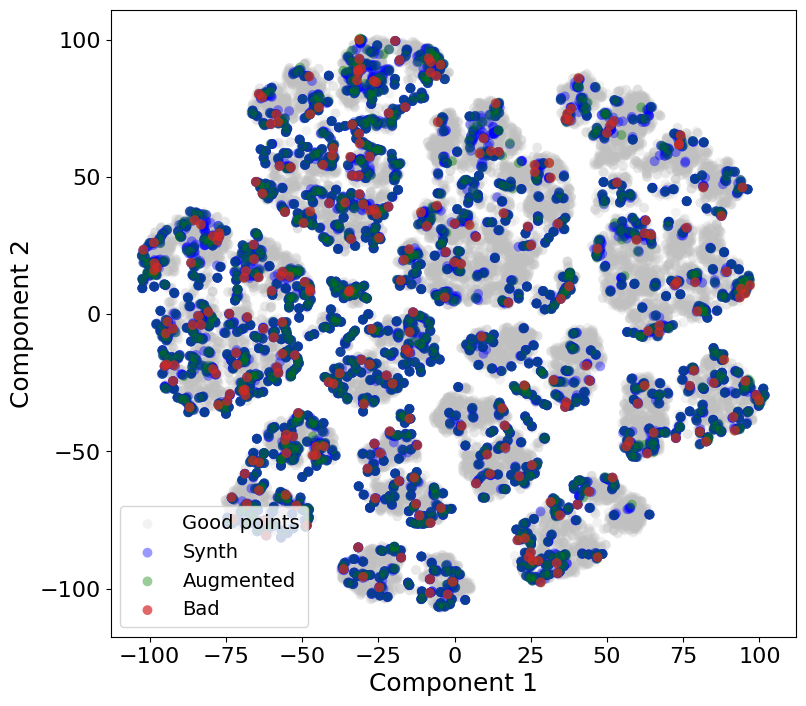

In [350]:
plt.subplots(figsize=(8, 7))



plt.scatter(pca_components4[:, 0], pca_components4[:, 1], color='silver', alpha=0.2, label='Good points', edgecolors='none', s=50)

# plt.scatter(pca_components1[:, 0], pca_components1[:, 1], c=clusters, s=50, alpha=1, cmap='viridis', edgecolors='none', label='Clusters of bad points')
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Cluster centroids')


plt.scatter(pca_components3[:, 0], pca_components3[:, 1], color='blue', alpha=0.4, label='Synth', edgecolors='none', s=50)
plt.scatter(pca_components2[:, 0], pca_components2[:, 1], color='green', alpha=0.4, label='Augmented', edgecolors='none', s=50)
plt.scatter(pca_components1[:, 0], pca_components1[:, 1], color='tab:red', alpha=0.7, label='Bad', edgecolors='none', s=50)




plt.legend(loc='lower left')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout(pad=0.5)
# plt.savefig('images/tsne_clf.pdf', dpi=300)
plt.show()

In [248]:
# plt.subplots(figsize=(6, 5))

# plt.scatter(pca_components3[:, 0], pca_components3[:, 1], color='blue', alpha=0.4, label='Synth', edgecolors='none', s=50)
# plt.scatter(pca_components2[:, 0], pca_components2[:, 1], color='green', alpha=0.4, label='Augmented', edgecolors='none', s=50)
# plt.scatter(pca_components1[:, 0], pca_components1[:, 1], color='tab:red', alpha=0.7, label='Bad', edgecolors='none', s=50)

# plt.legend()
# plt.xlabel('Component 1')
# plt.ylabel('Component 2')
# plt.tight_layout(pad=0.5)
# # plt.savefig('images/tsne_clf.pdf', dpi=300)
# plt.show()

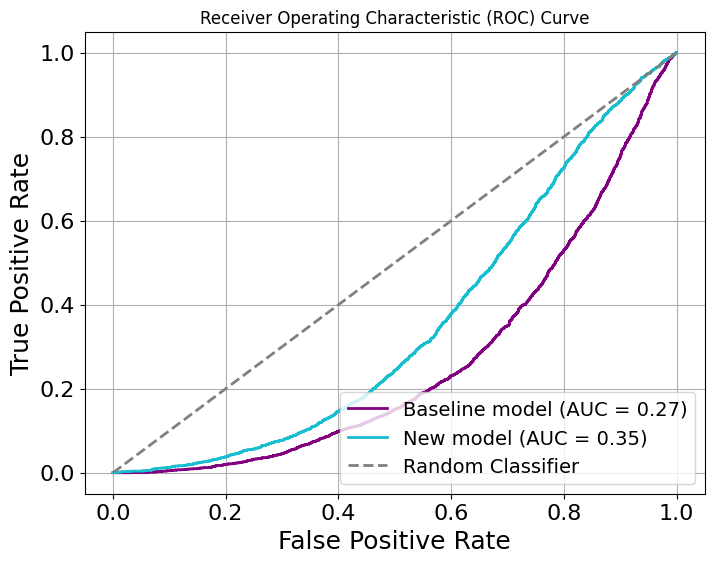

In [333]:
fpr1, tpr1, _ = roc_curve(synth_df.iloc[:, -1], baseline_model.predict_proba(synth_df.iloc[:, :-1].values)[:, 1])
roc_auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(synth_df.iloc[:, -1], new_model.predict_proba(synth_df.iloc[:, :-1].values)[:, 1])
roc_auc2 = auc(fpr2, tpr2)

# 7. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, color='purple', lw=2, label=f'Baseline model (AUC = {roc_auc1:.2f})')
plt.plot(fpr2, tpr2, color='tab:cyan', lw=2, label=f'New model (AUC = {roc_auc2:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier') # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

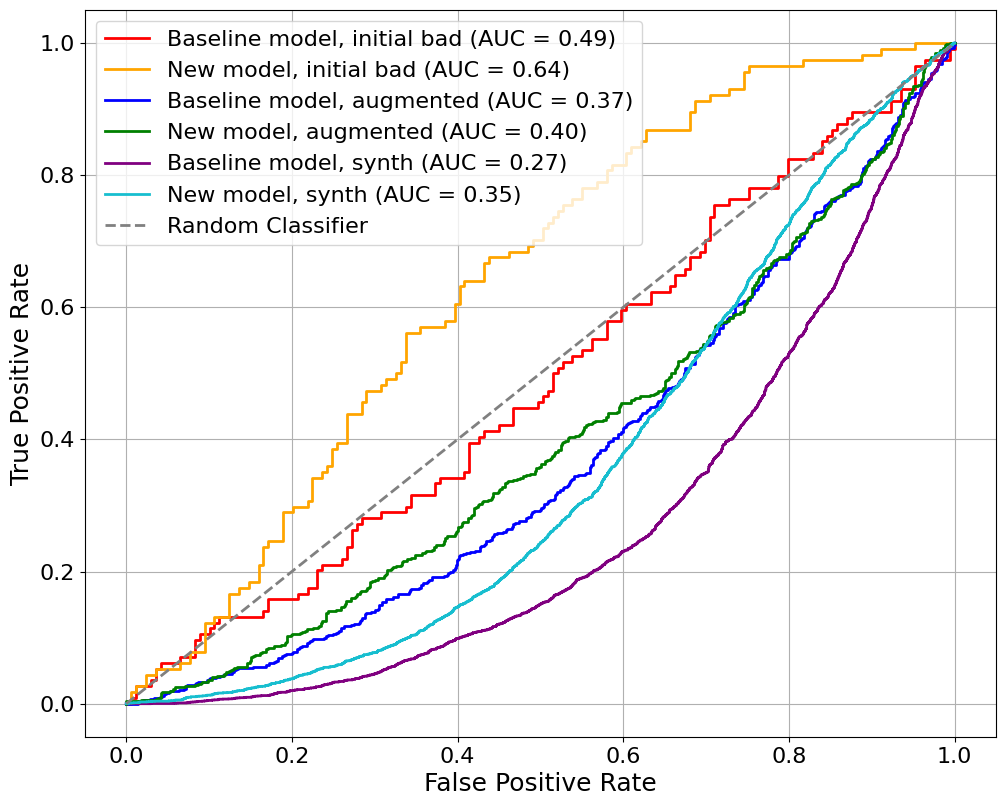

In [ ]:
fpr1, tpr1, _ = roc_curve(bad_y, baseline_model.predict_proba(bad_X)[:, 1])
roc_auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(bad_y, new_model.predict_proba(bad_X)[:, 1])
roc_auc2 = auc(fpr2, tpr2)
fpr3, tpr3, _ = roc_curve(bad_y_sc_arr, baseline_model.predict_proba(best_individuals)[:, 1])
roc_auc3 = auc(fpr3, tpr3)
fpr4, tpr4, _ = roc_curve(bad_y_sc_arr, new_model.predict_proba(best_individuals)[:, 1])
roc_auc4 = auc(fpr4, tpr4)
fpr5, tpr5, _ = roc_curve(synth_df.iloc[:, -1], baseline_model.predict_proba(synth_df.iloc[:, :-1])[:, 1])
roc_auc5 = auc(fpr5, tpr5)
fpr6, tpr6, _ = roc_curve(synth_df.iloc[:, -1], new_model.predict_proba(synth_df.iloc[:, :-1].values)[:, 1])
roc_auc6 = auc(fpr6, tpr6)

# 7. Plot the ROC curve
plt.figure(figsize=(10, 8))

plt.plot(fpr1, tpr1, color='red', lw=2, label=f'Baseline model, initial bad (AUC = {roc_auc1:.2f})')
plt.plot(fpr2, tpr2, color='orange', lw=2, label=f'New model, initial bad (AUC = {roc_auc2:.2f})')
plt.plot(fpr3, tpr3, color='blue', lw=2, label=f'Baseline model, augmented (AUC = {roc_auc3:.2f})')
plt.plot(fpr4, tpr4, color='green', lw=2, label=f'New model, augmented (AUC = {roc_auc4:.2f})')
plt.plot(fpr5, tpr5, color='purple', lw=2, label=f'Baseline model, synth (AUC = {roc_auc5:.2f})')
plt.plot(fpr6, tpr6, color='tab:cyan', lw=2, label=f'New model, synth (AUC = {roc_auc6:.2f})')


plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier') # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='upper left', fontsize=16)
plt.grid(True)

plt.tight_layout(pad=0.5)
# plt.savefig('images/roc_curve_all.pdf', dpi=300)
plt.show()

In [ ]:
# def smape(A, F):
#     return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F) + np.finfo(float).eps))

In [ ]:
# def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model, num_trials: int = 31):
#     # evaluate_model(XGBRegressor(), X, y)
    
#     eval_metrics = {'f1_aug_b': [], 'f1_bad_b': [], 'f1_synth_b': [],
#                     'f1_aug_n': [], 'f1_bad_n': [], 'f1_synth_n': [],
#                     'rocauc_aug_b': [], 'rocauc_bad_b': [], 'rocauc_synth_b': [],
#                     'rocauc_aug_n': [], 'rocauc_bad_n': [], 'rocauc_synth_n': [],
#                     'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
#                     'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': []}
    
    
#     # num_columns = X.select_dtypes(include=[np.number]).columns.tolist()
#     # cat_columns = np.setdiff1d(X.columns, num_columns)
#     # length_cat_ordinal = len(cat_columns)
#     # length_cat_onehot = []
#     # length_num = len(num_columns)
#     # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': length_cat_onehot, 'length_num': length_num}
    
#     # num_columns = np.setdiff1d(X_ex.columns, ['Квартиры среднего качества (типовые)'])
#     # cat_columns = ['Квартиры среднего качества (типовые)']

#     # length_cat_ordinal = len(cat_columns)
#     # length_cat_onehot = []
#     # # length_num = len(X.iloc[0])
#     # length_num = len(num_columns)

#     # length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}
    
    
#     for _ in range(num_trials):
#         X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
        
#         baseline_model = train_model(baseline_model, X_train, y_train)
#         new_model = train_model(new_model, X_train, y_train)
#         baseline_prediction = baseline_model.predict(X_test).flatten()
        
#         bad_X, bad_y = select_bad_examples(X_test, y_test, baseline_prediction, 0.1)
        
#         best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, [], length_dict, num_steps=20)
#         bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), baseline_model.predict(best_individuals))
        
#         idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
#         np.random.shuffle(idx_rnd)

#         augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
#         augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
#         augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
        
        
#         data_tensor = np.array(augmented_data).astype('float32')
#         data_tensor = torch.tensor(data_tensor)
        
        
        
#         batch_size = 2**7
#         seq_length = len(augmented_data[0]) - 1
#         input_channels = 1
#         train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1).to(device), batch_size=batch_size, shuffle=True)
#         model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=16).to(device)
#         losses_vae = train_vae(model_vae, train_loader, num_epochs=1000, learning_rate=1e-3)
        
#         model_vae.eval()
#         synth_vae_arr = []
#         for _ in range(5):
#             synth_vae, mu, logvar = model_vae(data_tensor.unsqueeze(1).to(device))
#             synth_vae = synth_vae.squeeze(1).detach().cpu().numpy()
#             synth_vae_arr.append(synth_vae)
            
#         synth_vae = np.vstack(np.array(synth_vae_arr))
#         # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
#                                                 # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
                                                
#         synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
        
#         # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
#         # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
        
#         X_tilde = synth_df.iloc[:, :-1]
#         X_tilde.columns = X_train.columns

#         synth_pred = baseline_model.predict(X_tilde)
#         new_model_synth_pred = new_model.predict(X_tilde)
        
        
#         f1_aug_b = f1_score(augmented_y, baseline_model.predict(augmented_X))
#         f1_bad_b = f1_score(bad_y.values.flatten(), baseline_model.predict(bad_X))
#         f1_synth_b = f1_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())
        
#         f1_aug_n = f1_score(augmented_y, new_model.predict(augmented_X))
#         f1_bad_n = f1_score(bad_y.values.flatten(), new_model.predict(bad_X))
#         f1_synth_n = f1_score(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
        
#         rocauc_aug_b = roc_auc_score(augmented_y, baseline_model.predict(augmented_X))
#         rocauc_bad_b = roc_auc_score(bad_y.values.flatten(), baseline_model.predict(bad_X))
#         rocauc_synth_b = roc_auc_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())

#         rocauc_aug_n = roc_auc_score(augmented_y, new_model.predict(augmented_X))
#         rocauc_bad_n = roc_auc_score(bad_y.values.flatten(), new_model.predict(bad_X))
#         rocauc_synth_n = roc_auc_score(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        

#         # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
#         # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
#         # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
        
#         # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
#         # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
#         # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
#         r2_aug_b = r2_score(augmented_y, baseline_model.predict(augmented_X))
#         r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X))
#         r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten())
        
#         r2_aug_n = r2_score(augmented_y, new_model.predict(augmented_X))
#         r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X))
#         r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
        
        
        
        
#         eval_metrics['f1_aug_b'].append(f1_aug_b)
#         eval_metrics['f1_bad_b'].append(f1_bad_b)
#         eval_metrics['f1_synth_b'].append(f1_synth_b)
        
#         eval_metrics['f1_aug_n'].append(f1_aug_n)
#         eval_metrics['f1_bad_n'].append(f1_bad_n)
#         eval_metrics['f1_synth_n'].append(f1_synth_n)
        

#         eval_metrics['rocauc_aug_b'].append(rocauc_aug_b)
#         eval_metrics['rocauc_bad_b'].append(rocauc_bad_b)
#         eval_metrics['rocauc_synth_b'].append(rocauc_synth_b)

#         eval_metrics['rocauc_aug_n'].append(rocauc_aug_n)
#         eval_metrics['rocauc_bad_n'].append(rocauc_bad_n)
#         eval_metrics['rocauc_synth_n'].append(rocauc_synth_n)

        
#         eval_metrics['r2_aug_b'].append(r2_aug_b)
#         eval_metrics['r2_bad_b'].append(r2_bad_b)
#         eval_metrics['r2_synth_b'].append(r2_synth_b)
        
#         eval_metrics['r2_aug_n'].append(r2_aug_n)
#         eval_metrics['r2_bad_n'].append(r2_bad_n)
#         eval_metrics['r2_synth_n'].append(r2_synth_n)
        
#     eval_df_baseline = pd.DataFrame([
#                             [f"{np.mean(eval_metrics['f1_aug_b']):.2f}+-{np.std(eval_metrics['f1_aug_b']):.2f}", 
#                              f"{np.mean(eval_metrics['f1_bad_b']):.2f}+-{np.std(eval_metrics['f1_bad_b']):.2f}",
#                              f"{np.mean(eval_metrics['f1_synth_b']):.2f}+-{np.std(eval_metrics['f1_synth_b']):.2f}"], 
                            
#                             [f"{np.mean(eval_metrics['rocauc_aug_b']):.2f}+-{np.std(eval_metrics['rocauc_aug_b']):.2f}", 
#                              f"{np.mean(eval_metrics['rocauc_bad_b']):.2f}+-{np.std(eval_metrics['rocauc_bad_b']):.2f}",
#                              f"{np.mean(eval_metrics['rocauc_synth_b']):.2f}+-{np.std(eval_metrics['rocauc_synth_b']):.2f}"],
                            
#                             [f"{np.mean(eval_metrics['r2_aug_b']):.2f}+-{np.std(eval_metrics['r2_aug_b']):.2f}", 
#                              f"{np.mean(eval_metrics['r2_bad_b']):.2f}+-{np.std(eval_metrics['r2_bad_b']):.2f}",
#                              f"{np.mean(eval_metrics['r2_synth_b']):.2f}+-{np.std(eval_metrics['r2_synth_b']):.2f}"]
#                             ],
#                            columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['mse', 'smape', 'r2'])
    
#     eval_df_new = pd.DataFrame([
#                             [f"{np.mean(eval_metrics['f1_aug_n']):.2f}+-{np.std(eval_metrics['f1_aug_n']):.2f}", 
#                              f"{np.mean(eval_metrics['f1_bad_n']):.2f}+-{np.std(eval_metrics['f1_bad_n']):.2f}",
#                              f"{np.mean(eval_metrics['f1_synth_n']):.2f}+-{np.std(eval_metrics['f1_synth_n']):.2f}"], 
                            
#                             [f"{np.mean(eval_metrics['rocauc_aug_n']):.2f}+-{np.std(eval_metrics['rocauc_aug_n']):.2f}", 
#                              f"{np.mean(eval_metrics['rocauc_bad_n']):.2f}+-{np.std(eval_metrics['rocauc_bad_n']):.2f}",
#                              f"{np.mean(eval_metrics['rocauc_synth_n']):.2f}+-{np.std(eval_metrics['rocauc_synth_n']):.2f}"],
                            
#                             [f"{np.mean(eval_metrics['r2_aug_n']):.2f}+-{np.std(eval_metrics['r2_aug_n']):.2f}", 
#                              f"{np.mean(eval_metrics['r2_bad_n']):.2f}+-{np.std(eval_metrics['r2_bad_n']):.2f}",
#                              f"{np.mean(eval_metrics['r2_synth_n']):.2f}+-{np.std(eval_metrics['r2_synth_n']):.2f}"]
#                             ],
#                            columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['F1', 'ROC AUC', 'r2'])
    
#     return eval_df_baseline, eval_df_new

In [36]:
def experiment(X: pd.DataFrame, y: pd.DataFrame, baseline_model, new_model,
               num_trials: int = 31,
               alpha: float = 0.1,
               exp_num = '1',
               batch_size=127,
               num_steps=10,
               num_epochs=100):
    
    eval_metrics = {'f1_aug_b': [], 'f1_bad_b': [], 'f1_synth_b': [],
                    'f1_aug_n': [], 'f1_bad_n': [], 'f1_synth_n': [],
                    'rocauc_aug_b': [], 'rocauc_bad_b': [], 'rocauc_synth_b': [],
                    'rocauc_aug_n': [], 'rocauc_bad_n': [], 'rocauc_synth_n': [],
                    'r2_aug_b': [], 'r2_bad_b': [], 'r2_synth_b': [],
                    'r2_aug_n': [], 'r2_bad_n': [], 'r2_synth_n': [],
                    'wd': []}
    
    num_columns = ['age', 'physical_activity_minutes_per_week',
    'bmi', 'cholesterol_total', 'insulin_level', 'heart_rate', 'diabetes_risk_score', 'glucose_fasting']
    cat_columns = ['gender', 'ethnicity', 'income_level', 'smoking_status']
    length_cat_ordinal = len(cat_columns)
    length_num = len(num_columns)
    length_dict = {'length_cat_ordinal': length_cat_ordinal, 'length_cat_onehot': [], 'length_num': length_num}
    
    baseline_model = baseline_model
    new_model = new_model
    
    for i in range(num_trials):
        try:
            X_train, X_test, y_train, y_test, scalers = split_and_transform(X, y)
            baseline_model = train_model(baseline_model, X_train, y_train)
            new_model = train_model(new_model, X_train, y_train)
            
            baseline_prediction = baseline_model.predict(X_test).flatten()
            baseline_prediction_proba = baseline_model.predict_proba(X_test)[:, 1].flatten()
            
            bad_X, bad_y = select_bad_examples(X_test, y_test,
                                               baseline_prediction,
                                               baseline_prediction_proba,
                                               alpha)
           
            # lr = LinearRegression(fit_intercept=False)
            # lr.fit(X_train.values, y_train.values)
            # linear_coefs = lr.coef_[0]
            
  
            best_individuals, bad_y_sc_arr = augmentation(bad_X, bad_y, baseline_model, [], length_dict, num_steps=num_steps)
            
            bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr),
                                                     baseline_model.predict(best_individuals).flatten(),
                                                     baseline_model.predict_proba(best_individuals)[:, 1].flatten(),
                                                     alpha)
            
            idx_rnd = np.arange(len(bad_X) + len(bad_X_ga))
            np.random.shuffle(idx_rnd)

            augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])[idx_rnd]
            augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])[idx_rnd]
            augmented_data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)
            
            
            data_tensor = np.array(augmented_data).astype('float32')
            data_tensor = torch.tensor(data_tensor)
            
            model_vae, _ = train_vae(data_tensor, num_epochs=num_epochs, batch_size=batch_size, cat_target_flag=True)
            model_vae.eval()
            
            synth_vae = generate(model_vae, data_tensor)
            # synth_df = pd.DataFrame(np.concatenate([scalers['scaler_X'].inverse_transform(synth_vae),
                                                    # scalers['scaler_y'].inverse_transform(data_tensor[:, -1].repeat(10).reshape(-1, 1))], axis=1))
            wd = np.mean(list(map(lambda x, y: wasserstein_distance(x, y), synth_vae.T, augmented_data.T)))
            eval_metrics['wd'].append(wd)
                                                    
            synth_df = pd.DataFrame(np.concatenate([synth_vae, data_tensor[:, -1].repeat(5).reshape(-1, 1)], axis=1))
            
            # synth_pred = baseline_model.predict(synth_df.drop(2, axis=1))
            # new_model_synth_pred = new_model.predict(synth_df.drop(2, axis=1))
            
            X_tilde = synth_df.iloc[:, :-1]
            X_tilde.columns = X_train.columns

            synth_pred = baseline_model.predict(X_tilde)
            new_model_synth_pred = new_model.predict(X_tilde)
            
            np.savez(f'Checkpoints/baseline_pred_exp{exp_num}_iter_{i+1}.npz', bad=baseline_model.predict(bad_X).flatten(), aug=baseline_model.predict(augmented_X).flatten(), synth=synth_pred.flatten())
            np.savez(f'Checkpoints/new_model_pred_exp{exp_num}_iter_{i+1}.npz', bad=new_model.predict(bad_X).flatten(), aug=new_model.predict(augmented_X).flatten(), synth=new_model_synth_pred.flatten())
            np.savez(f'Checkpoints/data_exp{exp_num}_iter_{i+1}.npz', bad=bad_y.values.flatten(), aug=augmented_y.flatten(), synth=data_tensor[:, -1].repeat(5).numpy().flatten())
            
            
            
            f1_aug_b = f1_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            f1_bad_b = f1_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            f1_synth_b = f1_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            f1_aug_n = f1_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            f1_bad_n = f1_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            f1_synth_n = f1_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            rocauc_aug_b = roc_auc_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            rocauc_bad_b = roc_auc_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            rocauc_synth_b = roc_auc_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())

            rocauc_aug_n = roc_auc_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            rocauc_bad_n = roc_auc_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            rocauc_synth_n = roc_auc_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())


            # mape_aug = mean_absolute_percentage_error(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # mape_bad = mean_absolute_percentage_error(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # mape_synth = mean_absolute_percentage_error(data_tensor[:, -1].repeat(10).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(10).numpy(), new_model_synth_pred.flatten())
            
            # r2_aug = r2_score(augmented_y, baseline_model.predict(augmented_X)), mean_squared_error(augmented_y, new_model.predict(augmented_X))
            # r2_bad = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_model.predict(bad_X))
            # r2_synth = r2_score(data_tensor[:, -1].repeat(5).numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].repeat(5).numpy(), new_model_synth_pred.flatten())
            
            r2_aug_b = r2_score(augmented_y.flatten(), baseline_model.predict(augmented_X).flatten())
            r2_bad_b = r2_score(bad_y.values.flatten(), baseline_model.predict(bad_X).flatten())
            r2_synth_b = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), synth_pred.flatten())
            
            r2_aug_n = r2_score(augmented_y.flatten(), new_model.predict(augmented_X).flatten())
            r2_bad_n = r2_score(bad_y.values.flatten(), new_model.predict(bad_X).flatten())
            r2_synth_n = r2_score(data_tensor[:, -1].repeat(5).numpy().flatten(), new_model_synth_pred.flatten())
            
            
        
            
            eval_metrics['f1_aug_b'].append(f1_aug_b)
            eval_metrics['f1_bad_b'].append(f1_bad_b)
            eval_metrics['f1_synth_b'].append(f1_synth_b)
            
            eval_metrics['f1_aug_n'].append(f1_aug_n)
            eval_metrics['f1_bad_n'].append(f1_bad_n)
            eval_metrics['f1_synth_n'].append(f1_synth_n)
            

            eval_metrics['rocauc_aug_b'].append(rocauc_aug_b)
            eval_metrics['rocauc_bad_b'].append(rocauc_bad_b)
            eval_metrics['rocauc_synth_b'].append(rocauc_synth_b)

            eval_metrics['rocauc_aug_n'].append(rocauc_aug_n)
            eval_metrics['rocauc_bad_n'].append(rocauc_bad_n)
            eval_metrics['rocauc_synth_n'].append(rocauc_synth_n)

            
            eval_metrics['r2_aug_b'].append(r2_aug_b)
            eval_metrics['r2_bad_b'].append(r2_bad_b)
            eval_metrics['r2_synth_b'].append(r2_synth_b)
            
            eval_metrics['r2_aug_n'].append(r2_aug_n)
            eval_metrics['r2_bad_n'].append(r2_bad_n)
            eval_metrics['r2_synth_n'].append(r2_synth_n)
            
        except Exception as e:
            print(e)
            continue
        
    np.save(f'Checkpoints/eval_metrics_exp{exp_num}.npy', eval_metrics)
        
    eval_df_baseline = pd.DataFrame([
                            [f"{np.mean(eval_metrics['f1_aug_b']):.4f}+-{np.std(eval_metrics['f1_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['f1_bad_b']):.4f}+-{np.std(eval_metrics['f1_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['f1_synth_b']):.4f}+-{np.std(eval_metrics['f1_synth_b']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['rocauc_aug_b']):.4f}+-{np.std(eval_metrics['rocauc_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['rocauc_bad_b']):.4f}+-{np.std(eval_metrics['rocauc_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['rocauc_synth_b']):.4f}+-{np.std(eval_metrics['rocauc_synth_b']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_b']):.4f}+-{np.std(eval_metrics['r2_aug_b']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_b']):.4f}+-{np.std(eval_metrics['r2_bad_b']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_b']):.4f}+-{np.std(eval_metrics['r2_synth_b']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['F1', 'ROC AUC', 'r2', 'wd'])
    
    eval_df_new = pd.DataFrame([
                            [f"{np.mean(eval_metrics['f1_aug_n']):.4f}+-{np.std(eval_metrics['f1_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['f1_bad_n']):.4f}+-{np.std(eval_metrics['f1_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['f1_synth_n']):.4f}+-{np.std(eval_metrics['f1_synth_n']):.4f}"], 
                            
                            [f"{np.mean(eval_metrics['rocauc_aug_n']):.4f}+-{np.std(eval_metrics['rocauc_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['rocauc_bad_n']):.4f}+-{np.std(eval_metrics['rocauc_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['rocauc_synth_n']):.4f}+-{np.std(eval_metrics['rocauc_synth_n']):.4f}"],
                            
                            [f"{np.mean(eval_metrics['r2_aug_n']):.4f}+-{np.std(eval_metrics['r2_aug_n']):.4f}", 
                            f"{np.mean(eval_metrics['r2_bad_n']):.4f}+-{np.std(eval_metrics['r2_bad_n']):.4f}",
                            f"{np.mean(eval_metrics['r2_synth_n']):.4f}+-{np.std(eval_metrics['r2_synth_n']):.4f}"],
                            
                            ["-",
                            "-",
                            f"{np.mean(eval_metrics['wd']):.4f}+-{np.std(eval_metrics['wd']):.4f}"],
                            
                            ],
                        columns=['AUG, MEAN+STD', 'BAD, MEAN+STD', 'SYNTH, MEAN+STD'], index=['F1', 'ROC AUC', 'r2', 'wd'])
        
    eval_df_baseline.to_csv(f'Checkpoints/eval_df_baseline_exp{exp_num}.csv', header=True, index=True)
    eval_df_new.to_csv(f'Checkpoints/eval_df_new_exp{exp_num}.csv', header=True, index=True)
    
    return eval_df_baseline, eval_df_new

In [37]:
# baseline_model = train_model(LinearRegression(), X_train, y_train)
# new_model = train_model(XGBRegressor(), X_train, y_train)

In [38]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
alphas = [0.501, 0.502, 0.505]
batch_sizes = [2**6, 2**7, 2**8]
num_steps = [8, 5, 3]
num_epochs = [100, 100, 200]

In [48]:
for i in range(len(alphas)):
    eval_df_baseline, eval_df_new = experiment(X_ex, y_ex,
                                               RandomForestClassifier(n_estimators=200, max_depth=3),
                                               XGBClassifier(n_estimators=200, max_depth=3),
                                               num_trials=31, alpha=alphas[i], exp_num=f'_clf_alpha_{i+1}',
                                               batch_size=batch_sizes[i], num_steps=num_steps[i], num_epochs=num_epochs[i])

Average Loss: 0.0006, LR: 0.0001: 100%|██████████| 200/200 [00:24<00:00,  8.11it/s]


In [49]:
eval_df_baseline

,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
F1,0.4720+-0.0359,0.4670+-0.0367,0.3954+-0.1078
ROC AUC,0.5092+-0.0241,0.5081+-0.0248,0.4968+-0.0402
r2,-0.9951+-0.0912,-1.0021+-0.0944,-1.0046+-0.1685
wd,-,-,0.0380+-0.0047


In [50]:
eval_df_new

,"AUG, MEAN+STD","BAD, MEAN+STD","SYNTH, MEAN+STD"
F1,0.3965+-0.0647,0.4241+-0.0636,0.1168+-0.0867
ROC AUC,0.5438+-0.0228,0.5522+-0.0244,0.5222+-0.0244
r2,-0.7471+-0.0860,-0.7225+-0.0919,-0.7216+-0.1209
wd,-,-,0.0380+-0.0047


In [51]:
318/60

5.3

In [60]:
print(pd.read_csv('Checkpoints/eval_df_baseline_exp_clf_alpha_3.csv').to_latex())

\begin{tabular}{lllll}
\toprule
 & Unnamed: 0 & AUG, MEAN+STD & BAD, MEAN+STD & SYNTH, MEAN+STD \\
\midrule
0 & F1 & 0.4720+-0.0359 & 0.4670+-0.0367 & 0.3954+-0.1078 \\
1 & ROC AUC & 0.5092+-0.0241 & 0.5081+-0.0248 & 0.4968+-0.0402 \\
2 & r2 & -0.9951+-0.0912 & -1.0021+-0.0944 & -1.0046+-0.1685 \\
3 & wd & - & - & 0.0380+-0.0047 \\
\bottomrule
\end{tabular}



In [61]:
print(pd.read_csv('Checkpoints/eval_df_new_exp_clf_alpha_3.csv').to_latex())

\begin{tabular}{lllll}
\toprule
 & Unnamed: 0 & AUG, MEAN+STD & BAD, MEAN+STD & SYNTH, MEAN+STD \\
\midrule
0 & F1 & 0.3965+-0.0647 & 0.4241+-0.0636 & 0.1168+-0.0867 \\
1 & ROC AUC & 0.5438+-0.0228 & 0.5522+-0.0244 & 0.5222+-0.0244 \\
2 & r2 & -0.7471+-0.0860 & -0.7225+-0.0919 & -0.7216+-0.1209 \\
3 & wd & - & - & 0.0380+-0.0047 \\
\bottomrule
\end{tabular}



In [45]:
np.load('Checkpoints/baseline_pred_exp_clf_alpha_1_iter_1.npz')['bad']

array([0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1.])

In [189]:
np.load('Checkpoints/new_model_pred_exp_clf_alpha_1_iter_1.npz')['bad']

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1])

In [187]:
np.load('Checkpoints/data_exp_clf_alpha_1_iter_1.npz')['bad']

array([0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0.,
       0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0.,
       1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1.,
       0., 1., 1., 0., 0.